This notebook illustrates the half plane representation of a convex polygon, using numpy, scipy (in particular qhull), and matplotlib.

# 1. Plotting a Random Polygon

In [1]:
import numpy as np

In [2]:
from scipy.spatial import ConvexHull
from scipy.spatial import convex_hull_plot_2d

In [3]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from matplotlib import quiver

In [4]:
N = 10

In [5]:
points = np.random.rand(N, 2)
points

array([[0.11159549, 0.55305788],
       [0.65240219, 0.47488414],
       [0.13139606, 0.47588535],
       [0.10109934, 0.83657045],
       [0.36532896, 0.52978316],
       [0.19761354, 0.43429364],
       [0.10265432, 0.27567933],
       [0.65295611, 0.09324705],
       [0.4485879 , 0.87635975],
       [0.3113935 , 0.19765463]])

In [6]:
hull = ConvexHull(points)

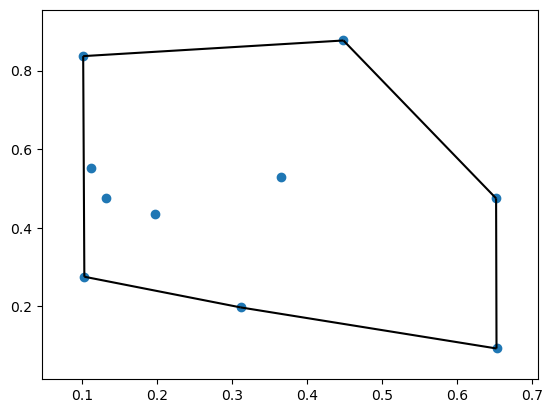

In [7]:
convex_hull_plot_2d(hull)
plt.show()

In [8]:
eqs = hull.equations
eqs

array([[-0.11376199,  0.99350803, -0.8196382 ],
       [-0.99999616, -0.00277232,  0.1034182 ],
       [ 0.99999895,  0.00145144, -0.65309076],
       [ 0.89167734,  0.45267154, -0.79669878],
       [-0.2923241 , -0.95631931,  0.28004876],
       [-0.35012989, -0.93670116,  0.29417149]])

In [9]:
(a, b, c) = eqs[0]
(a, b, c)

(-0.11376199453210584, 0.9935080314723566, -0.8196381975039511)

According to the qhull documentation, the equation defined by $(a, b, c)$ is
$$
   a x + b y + c < 0.
$$

Let us draw the first line, computing slope and intercept from $(a, b, c)$.

In [10]:
slope = -a/b
slope

0.11450535972367845

In [11]:
intercept = -c/b
intercept

0.8249940328003847

In [12]:
line = lambda x: slope*x + intercept

In [13]:
r = np.linspace(0, 1, 10)
s = [line(x) for x in r]

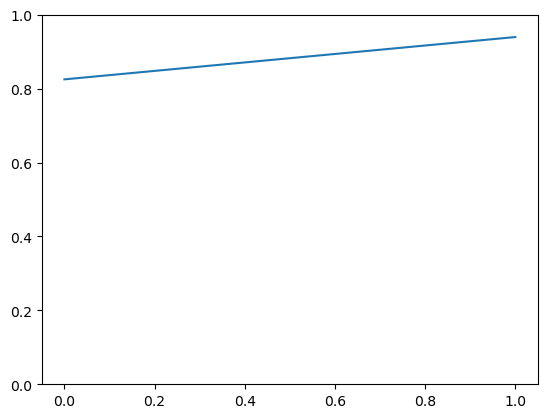

In [14]:
fig,ax = plt.subplots()
plt.ylim(0, 1)
plt.plot(r, s)
plt.show()

Now we can plot all lines that define the half planes.

In [15]:
colors = cm.jet(np.linspace(0,1,len(eqs)))

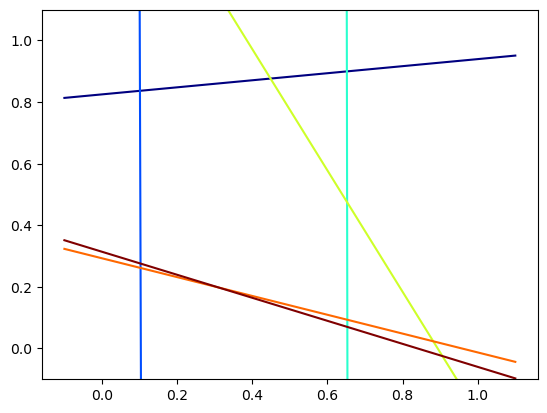

In [16]:
fig,ax = plt.subplots()
plt.ylim(-0.1, 1.1)
r = np.linspace(-0.1, 1.1, 10)
for k in range(len(eqs)):
    (a, b, c) = eqs[k]
    (slope, intercept) = (-a/b, -c/b)
    line = lambda x: slope*x + intercept
    s = [line(x) for x in r]
    plt.plot(r, s, color=colors[k])
plt.show()

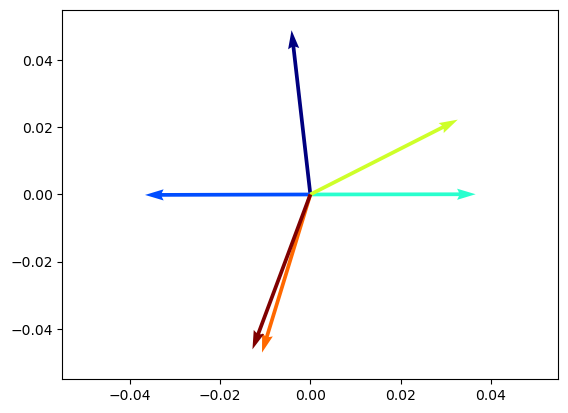

In [17]:
X = np.zeros(len(eqs))
Y = np.zeros(len(eqs))
U = eqs[:,0]
V = eqs[:,1]

fig, ax = plt.subplots()
q = ax.quiver(X, Y, U, V, scale=3, color=colors)

plt.show()

# 2. Three Plots in One Figure

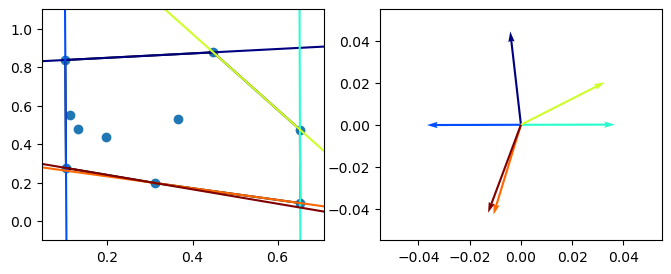

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(8,3), sharey=False)
convex_hull_plot_2d(hull, ax=axs[0])
axs[0].set_ylim(-0.1, 1.1)
r = np.linspace(-0.1, 1.1, 10)
for k in range(len(eqs)):
    (a, b, c) = eqs[k]
    (slope, intercept) = (-a/b, -c/b)
    line = lambda x: slope*x + intercept
    s = [line(x) for x in r]
    axs[0].plot(r, s, color=colors[k])
X = np.zeros(len(eqs))
Y = np.zeros(len(eqs))
U = eqs[:,0]
V = eqs[:,1]
q = axs[1].quiver(X, Y, U, V, scale=3, color=colors)
# plt.savefig('halfplanes.png')
plt.show()